# Quick-look for simulations

This notebook can be used to have a quicklook at the that product for the simulations.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [3]:
# Define path to data
path = '/lhome/nicholas/software/workdir/cs-exomoon/tests/test0/sims/000000004'

---
## Single mode
---

In [5]:
# Load a single mission quarter light curve
filename = f"{path}/000000004_Ncam1.1_Q1.hdf5"
lc = LightCurve(filename, mode="single")

In [6]:
# Fetch overview table
ds = lc.star()
ds.head()

,ID,PIC,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,4,2865660000186,103.889618,-55.244637,10.39,1,1,1,1,429.965770,3716.240813,4.163691,-9.039384,15.587665,3,0.460132
1,4,2865660000186,103.889618,-55.244637,10.39,1,1,2,4,3742.372275,3693.099782,15.898988,16.004204,68.662701,3,0.457818
2,4,2865660000186,103.889618,-55.244637,10.39,1,1,3,4,2332.335010,699.375953,18.372658,69.891233,43.282030,3,0.454910
3,4,2865660000186,103.889618,-55.244637,10.39,1,1,4,3,2219.862905,4062.101055,9.699340,41.257532,-9.362181,3,0.454643
4,4,2865660000186,103.889618,-55.244637,10.39,1,1,5,1,430.006389,3716.055382,4.164441,-9.040115,15.591003,3,0.458522


<IPython.core.display.Javascript object>


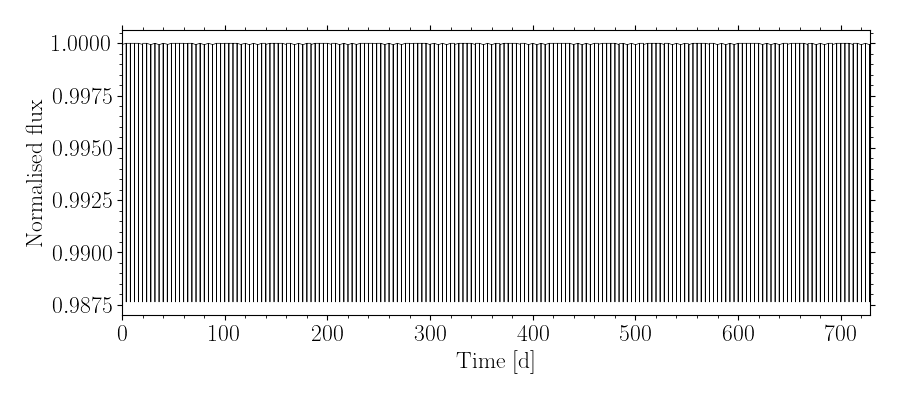

In [7]:
# Show in the injected variability
dv = lc.varsource()

fig, ax = plt.subplots(1, 1, figsize=(9,4))
ax.plot(dv.time/86400, dv.flux, 'k-', lw=0.5)
ax.set_xlabel('Time [d]')
ax.set_ylabel('Normalised flux')
ax.set_xlim(dv.time.min()/86400, dv.time.max()/86400)
plt.tight_layout();

In [8]:
# Fetch the data from the light curve object
lc.data().head()

,time,flux
0,0.0,139613.088881
1,25.0,139434.448703
2,50.0,139514.823086
3,75.0,139496.080341
4,100.0,139003.041383


<IPython.core.display.Javascript object>


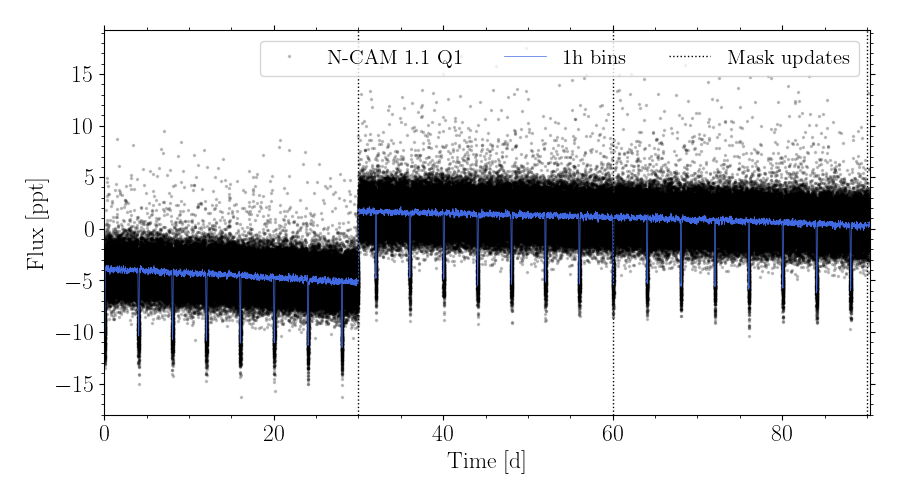

In [9]:
# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1);

### *Test post-processing*

<IPython.core.display.Javascript object>


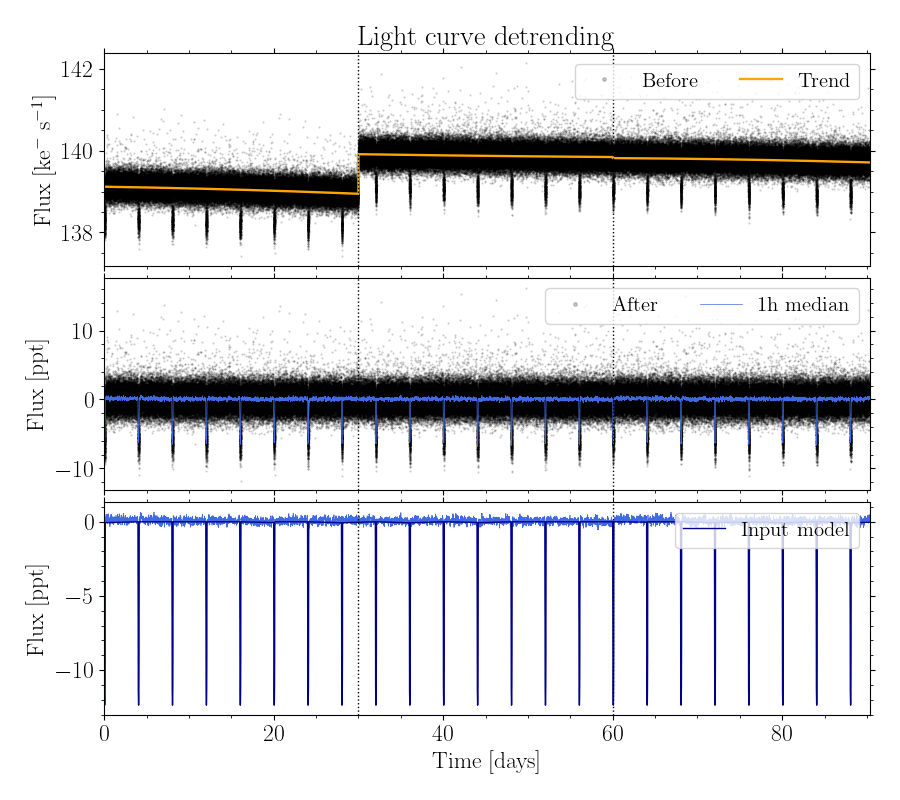

,time,flux,flux_trend,flux_detrend
0,0.0,139613.088881,139119.103223,1.003551
1,25.0,139434.448703,139119.102280,1.002267
2,50.0,139514.823086,139119.101337,1.002844
3,75.0,139496.080341,139119.100394,1.002710
4,100.0,139003.041383,139119.099451,0.999166


In [10]:
# Detrend light curve (segment=True if you want it to be done per mask update)
df = lc.detrend(model='poly', degree=2, segments=True, plot=True)
df.head()

<IPython.core.display.Javascript object>


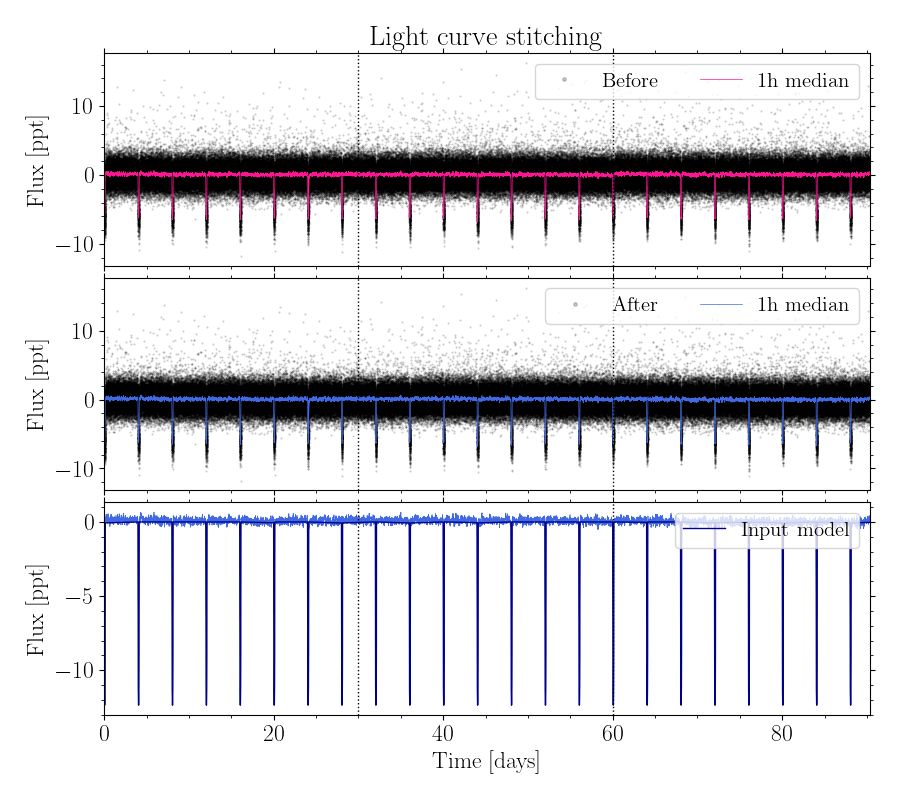

,time,flux,flux_trend,flux_detrend,flux_stitch
0,0.0,139613.088881,139119.103223,1.003551,1.003551
1,25.0,139434.448703,139119.102280,1.002267,1.002267
2,50.0,139514.823086,139119.101337,1.002844,1.002844
3,75.0,139496.080341,139119.100394,1.002710,1.002710
4,100.0,139003.041383,139119.099451,0.999166,0.999166


In [11]:
# Stitch the segments (only needed if detrending leaves big jumps)
df = lc.stitch(column='flux_detrend', method='median', gapsize=0.1, segment=5, plot=True)
df.head()

<IPython.core.display.Javascript object>


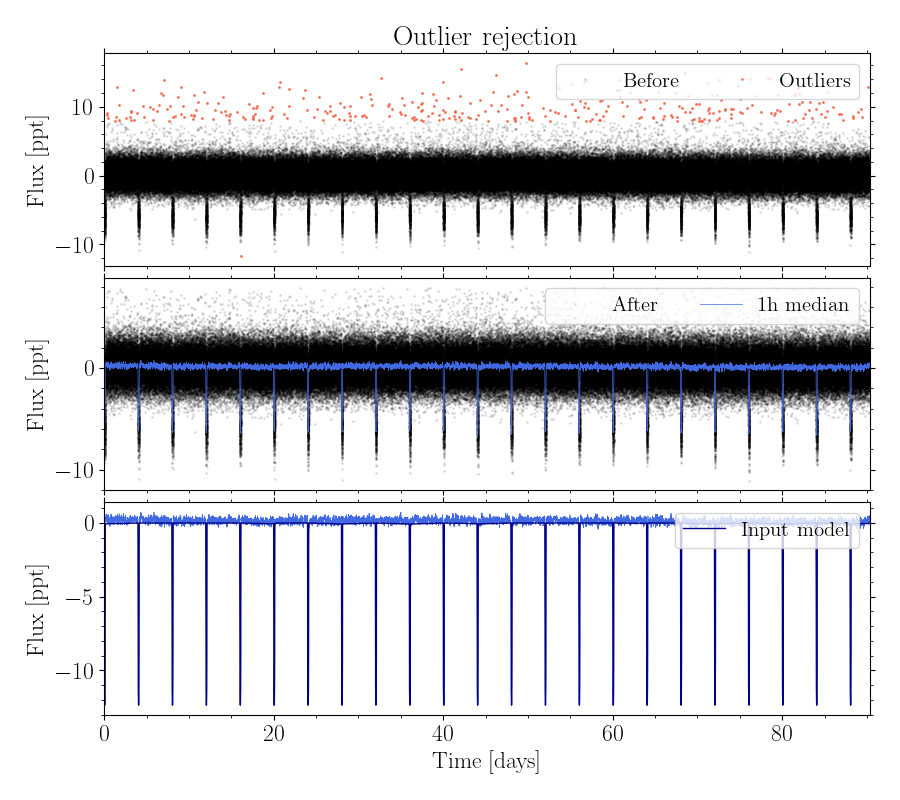

,time,flux,flux_trend,flux_detrend,flux_stitch,flux_clip
0,0.0,139613.088881,139119.103223,1.003551,1.003551,1.003551
1,25.0,139434.448703,139119.102280,1.002267,1.002267,1.002267
2,50.0,139514.823086,139119.101337,1.002844,1.002844,1.002844
3,75.0,139496.080341,139119.100394,1.002710,1.002710,1.002710
4,100.0,139003.041383,139119.099451,0.999166,0.999166,0.999166


In [15]:
# Remove outliers (due to photon noise and cosmic ray hits)
df = lc.clip(column='flux_stitch', magnitude=ds.mag.iloc[0], flux_unit='ppt', plot=True)
df.head()

---
## Multi mode
---

In [12]:
# In multi mode we parse the entire directory of files
lcs = LightCurve(path, mode="multi")

### *Use multi-mode as single-mode*

In [13]:
# Fetch files in folder
filenames = lcs.files(suffix='hdf5')
filenames[:3]

['/lhome/nicholas/software/workdir/cs-planet/tests/test0/sims/000000004/000000004_Ncam1.1_Q1.hdf5',
 '/lhome/nicholas/software/workdir/cs-planet/tests/test0/sims/000000004/000000004_Ncam1.1_Q2.hdf5',
 '/lhome/nicholas/software/workdir/cs-planet/tests/test0/sims/000000004/000000004_Ncam1.1_Q3.hdf5']

In [14]:
# Again one can fetch the first light curve for this star
lc = LightCurve(filenames[0])
lc.data().head()

,time,flux
0,0.0,139431.742732
1,25.0,139409.465857
2,50.0,139496.086928
3,75.0,139483.588919
4,100.0,139003.041383


### *Simulation statistics*

The `.table` files each contain a small overview of the specific simulation. It is much handier to have a single file to search information from, hence, we can merge to one single overview table as follows. It possible to remove the redundant `.table` files during the process using `clean=True`:

In [15]:
df = lcs.stat_sim_table(ofile=f'{path}/overview_table.ftr', clean=True)
df.head()

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.00it/s]                                                                         


,ID,PIC,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,4,2865660000186,103.889618,-55.244637,10.39,1,1,1,1,429.965770,3716.240813,4.163691,-9.039384,15.587665,3,0.460181
1,4,2865660000186,103.889618,-55.244637,10.39,1,1,2,4,3742.372275,3693.099782,15.898988,16.004204,68.662701,3,0.457893
2,4,2865660000186,103.889618,-55.244637,10.39,1,1,3,4,2332.335010,699.375953,18.372658,69.891233,43.282030,3,0.455003
3,4,2865660000186,103.889618,-55.244637,10.39,1,1,4,3,2219.862905,4062.101055,9.699340,41.257532,-9.362181,3,0.454748
4,4,2865660000186,103.889618,-55.244637,10.39,1,1,5,1,430.006389,3716.055382,4.164441,-9.040115,15.591003,3,0.458604


### *View simulations*

<IPython.core.display.Javascript object>


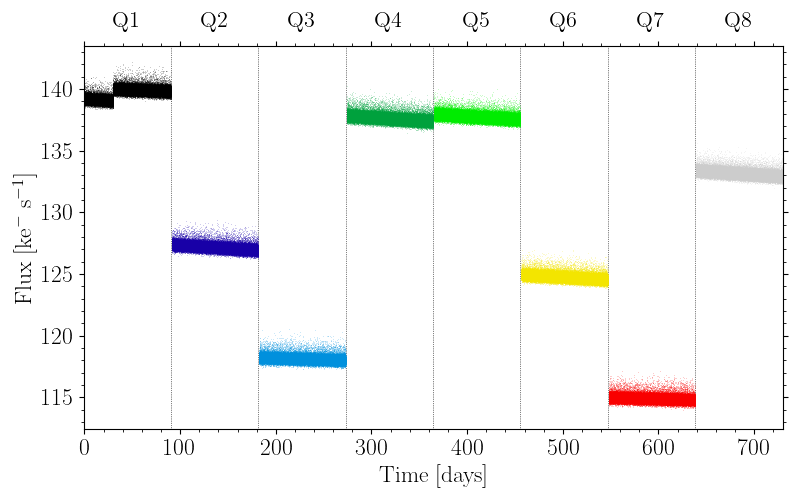

In [16]:
# Let's plot the light curves for N-CAM 1.1
fig, ax = lcs.plot_multi(suffix='hdf5', group=1, camera=1, quarter=False,
                         quarter_labels_ypos=145, figsize=(8,5))

<IPython.core.display.Javascript object>


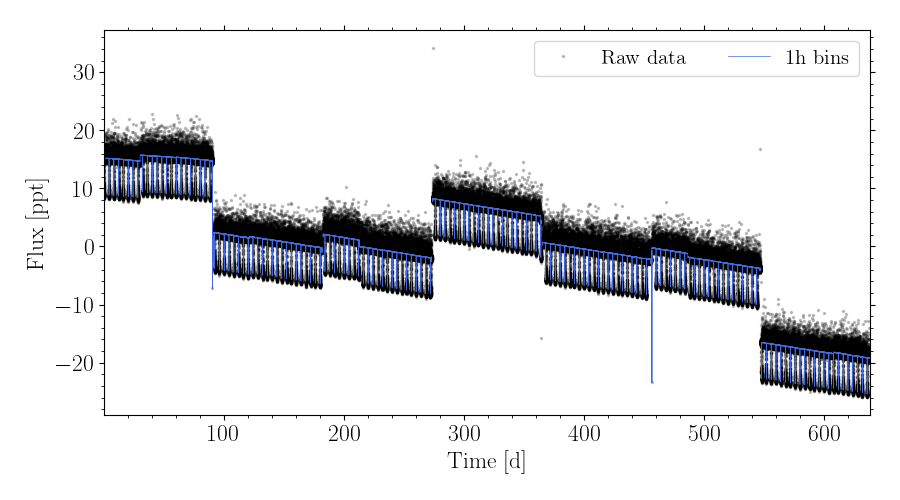

In [121]:
# Merge all light curves using post-processing (returns a light curve object)
lc = lcs.merge(flux_group_mean=True, binsize=50, suffix='hdf5')
lc.plot(flux_unit='ppt', median_filter=1);

---
## Multi-mode: post-processing
---

In [91]:
# df = lcs.stat_lcs_per_star()